## EDA

In [94]:
import pandas as pd 

train_df = pd.read_csv("../Datasets/sent_train.csv")
valid_df = pd.read_csv("../Datasets/sent_valid.csv")

print(train_df.shape)
print(valid_df.shape)

print(train_df.head())
print(valid_df.head())

(9543, 2)
(2388, 2)
                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0
                                                text  label
0  $ALLY - Ally Financial pulls outlook https://t...      0
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0
2  $PRTY - Moody's turns negative on Party City h...      0
3                   $SAN: Deutsche Bank cuts to Hold      0
4                  $SITC: Compass Point cuts to Sell      0


In [95]:
print(train_df.info())
print(valid_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2388 non-null   str  
 1   label   2388 non-null   int64
dtypes: int64(1), str(1)
memory usage: 241.4 KB
None


So, this shows that there are no null values.

In [96]:
train_df["label"].value_counts()

label
2    6178
1    1923
0    1442
Name: count, dtype: int64

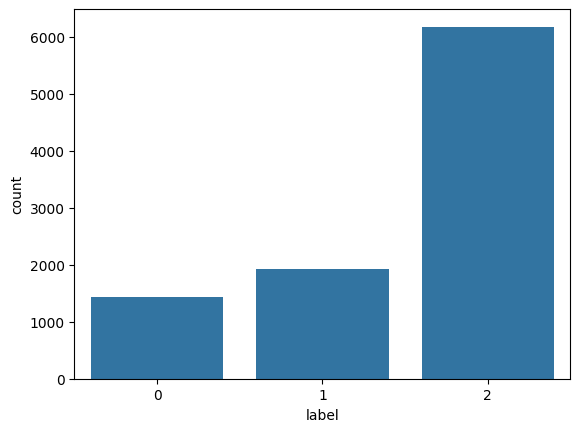

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train_df, x="label")
plt.show()

In [98]:
# Since we can see the split of bearish, bullish and neutral data, we can map them accordingly. 

label_map = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral"
}

train_df["sentiment"] = train_df["label"].map(label_map)
valid_df["sentiment"] = valid_df["label"].map(label_map)

print(train_df.head())
print(valid_df.head())


                                                text  label sentiment
0  $BYND - JPMorgan reels in expectations on Beyo...      0   Bearish
1  $CCL $RCL - Nomura points to bookings weakness...      0   Bearish
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0   Bearish
3  $ESS: BTIG Research cuts to Neutral https://t....      0   Bearish
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0   Bearish
                                                text  label sentiment
0  $ALLY - Ally Financial pulls outlook https://t...      0   Bearish
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0   Bearish
2  $PRTY - Moody's turns negative on Party City h...      0   Bearish
3                   $SAN: Deutsche Bank cuts to Hold      0   Bearish
4                  $SITC: Compass Point cuts to Sell      0   Bearish


In [99]:
# this is to check the word length of each row of the column 'text'

train_df["length"] = train_df["text"].apply(lambda x: len(x.split()))

train_df["length"].describe()

count    9543.000000
mean       12.178351
std         4.665599
min         1.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        32.000000
Name: length, dtype: float64

In [100]:
# this is just to understand data, if it has URLs, emails, etc.

for i in range(10):
    print(train_df["text"][i])
    print()

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT

$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3

$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb

$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N

$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB

$FTI - TechnipFMC downgraded at Berenberg but called Top Pick at Deutsche Bank https://t.co/XKcPDilIuU

$GM - GM loses a bull https://t.co/tdUfG5HbXy

$GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS

$GTT: Cowen cuts to Market Perform

$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone estimate after Foxconn delay https://t.co/rlnEwzlzzS



## Data Preprocessing

In [101]:
# to remove URLs, mentions and other extra spaces

import re

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text) # URLs
    text = re.sub(r'@\w+', '', text) # mentions
    text = re.sub(r'\s+', ' ', text) # extra spaces

    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_text)
valid_df["clean_text"] = valid_df["text"].apply(clean_text)

In [102]:
for i in range(5):
    print("Original:")
    print(train_df["text"][i])
    print("Cleaned:")
    print(train_df["clean_text"][i])
    print()

Original:
$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
Cleaned:
$BYND - JPMorgan reels in expectations on Beyond Meat

Original:
$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
Cleaned:
$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean

Original:
$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
Cleaned:
$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook

Original:
$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N
Cleaned:
$ESS: BTIG Research cuts to Neutral

Original:
$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB
Cleaned:
$FNKO - Funko slides after Piper Jaffray PT cut



In [103]:
# Tokenization
# Only on train dataset, so that evaluating on valid dataset could be fair, without foreseeing future


all_words = []

for text in train_df["clean_text"]:
    all_words.extend(text.split())

print("Total words:", len(all_words))
print("Unique words:", len(set(all_words)))

Total words: 110874
Unique words: 26326


In [104]:
# to create a vocabulary list (a dictionary of words)

vocab = {
    "<PAD>": 0, # for padding
    "<UNK>": 1 # unknown words
}

for word in set(all_words):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 26328


In [105]:
# to encode

def encode_text(text):
    tokens = text.split()
    return [vocab.get(word, vocab["<UNK>"]) for word in tokens]

train_df["encoded"] = train_df["clean_text"].apply(encode_text)
valid_df["encoded"] = valid_df["clean_text"].apply(encode_text)

train_df[["clean_text", "encoded"]].head()

,clean_text,encoded
0,$BYND - JPMorgan reels in expectations on Beyo...,"[16776, 12526, 20260, 8504, 2327, 160, 23726, ..."
1,$CCL $RCL - Nomura points to bookings weakness...,"[15165, 12338, 12526, 17778, 10271, 2205, 4534..."
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...","[17530, 12526, 5090, 1438, 3725, 2099, 3179, 1..."
3,$ESS: BTIG Research cuts to Neutral,"[13263, 20685, 13519, 14380, 2205, 8958]"
4,$FNKO - Funko slides after Piper Jaffray PT cut,"[25712, 12526, 18762, 16304, 9888, 10979, 1569..."


In [106]:
sample = train_df["clean_text"][0]

print("Original:")
print(sample)

print("Encoded:")
print(encode_text(sample))

Original:
$BYND - JPMorgan reels in expectations on Beyond Meat
Encoded:
[16776, 12526, 20260, 8504, 2327, 160, 23726, 18317, 11036]


In [107]:
train_df["length"].describe()

count    9543.000000
mean       12.178351
std         4.665599
min         1.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        32.000000
Name: length, dtype: float64

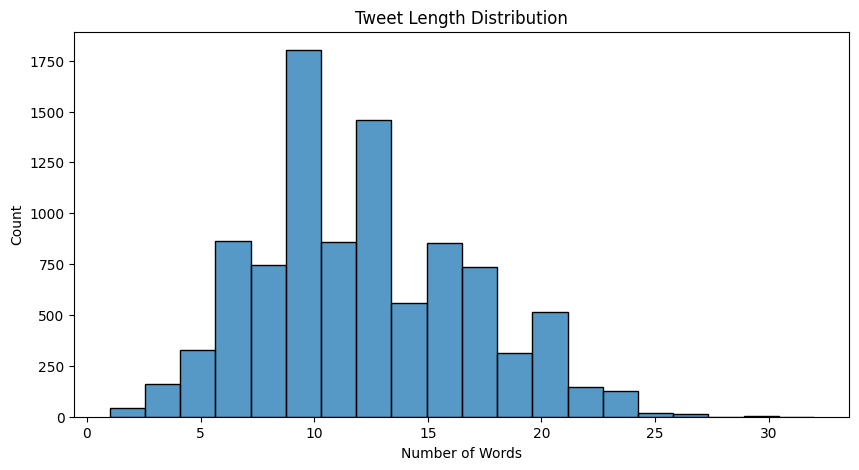

In [108]:
plt.figure(figsize=(10,5))
sns.histplot(train_df["length"], bins=20)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")

plt.show()

In [109]:
print((train_df["length"] > 20).sum())
print((train_df["length"] > 25).sum())

537
17


With the analysis from the above three code cells, tweet lengths showed a median length of 11 words, a 75th percentile of 15 words, and a maximum of 32 words. Since we need all length of each row to be exactly of the same size, we can perform padding. But, padding to the maximum length of 32 words would make it difficult for shorter tweets with more padded values. Hence, we choose an appropriate length of 25 words as max length as it would cover more than 90% of tweets, as only 17 tweets exceed this limit (which we can truncate later), and also we cannot choose 20 words as max length (eventhough it covers more than 75%), because as we can see in the previous code cell it would result in truncating more than 500 tweets causing loss of data.

In [110]:
# to perform padding

max_len = 25

def pad_sequence(sequence):
    if len(sequence) > max_len:
        return sequence[:max_len] # truncate extra words

    return sequence + [vocab["<PAD>"]] * (max_len - len(sequence)) # to add padding to remaining spaces after the actual text

train_df["padded"] = train_df["encoded"].apply(pad_sequence)
valid_df["padded"] = valid_df["encoded"].apply(pad_sequence)

In [111]:
print(len(train_df["padded"][0]))
print(train_df["padded"][10])

25
[18085, 12526, 21912, 23363, 23726, 4543, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Data Preparation

In [112]:
# to convert to tensors

import torch

X_train = torch.tensor(train_df["padded"].tolist())
y_train = torch.tensor(train_df["label"].tolist())

X_valid = torch.tensor(valid_df["padded"].tolist())
y_valid = torch.tensor(valid_df["label"].tolist())

print(X_train.shape)
print(y_train.shape)

torch.Size([9543, 25])
torch.Size([9543])


In [113]:
# to connect the x data and y data together as a dataset

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)

In [114]:
# to create a data loader for the Neural Network working (to split dataset into batches, as it uses batches of datasets)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32
)

## Model Building

### 1. Simple RNN model

In [115]:
# this is to reduce randomness of batch shuffling while training, as such shiffles can affect results each time we train or run the model

import torch
import numpy as np
import random

torch.manual_seed(32)
np.random.seed(32)
random.seed(32)

In [116]:
# first we evaluate using a simple RNN 

import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        # embeddiing_dim is the dimension of vectors after being converted from IDs, hidden_dim is for the memory for RNN to save after reading and understanding the text (Embedded Vectors)
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) # for embedding the words with trainable vectors
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes) # final linear layer

    def forward(self, x):
        embedded = self.embedding(x) # to convert IDs to vectors, so those vectors can decide and learn the words
        output, hidden = self.rnn(embedded) # after this step we only use hidden and not output, because hidden has the final memory of the tweet understandings, and output contains the memory updates at each step while understanding the tweet
        hidden = hidden.squeeze(0) # since we get a three dimension result where the first dimension shows that it is a RNN layer, and also it is not useful information
        out = self.fc(hidden) # because the RNN gives 128 featues of result, but we only need 3 results to check probablility among the three results (bearish, bullish, neutral)
        return out

In [117]:
# to set up the class_weights for the loss function to assign or update weights according to class imbalance

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced", # to indicate that the dataset is imbalanced
    classes=np.unique(train_df["label"]), # to give the unique type of classes
    y=train_df["label"] # to pass all label info to check for loss
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([2.2060, 1.6542, 0.5149])


In [118]:
# creating model object and setting up loss function and optimizer

vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
num_classes = 3

rnn_model = SimpleRNN(vocab_size, embedding_dim, hidden_dim, num_classes)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

In [119]:
epochs = 10

for epoch in range(epochs):
    rnn_model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # to start with zero old gradients
        outputs = rnn_model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward() # backpropogation
        optimizer.step() # to update
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 1.1007
Epoch 2, Loss: 1.0965
Epoch 3, Loss: 1.0913
Epoch 4, Loss: 1.0945
Epoch 5, Loss: 1.0803
Epoch 6, Loss: 1.0685
Epoch 7, Loss: 1.0262
Epoch 8, Loss: 0.9371
Epoch 9, Loss: 0.8178
Epoch 10, Loss: 0.6735


In [120]:
rnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        outputs = rnn_model(X_batch)
        predictions = torch.argmax(outputs, dim=1) # to simply pick the largest output value, for results
        all_preds.extend(predictions.tolist()) # just to store predictions in a list
        all_labels.extend(y_batch.tolist()) # just to store labels of y dataset in a list, to compare predictions and results

print(len(all_preds))
print(len(all_labels))

2388
2388


In [121]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score)
from sklearn.metrics import (recall_score, confusion_matrix, classification_report)

accuracy = accuracy_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds, average="macro") # we use macro since the dataset is imbalanced
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(classification_report(all_labels, all_preds))

Accuracy : 0.4393
Macro F1 : 0.3824
Precision: 0.4012
Recall   : 0.4153
              precision    recall  f1-score   support

           0       0.16      0.32      0.22       347
           1       0.30      0.47      0.37       475
           2       0.74      0.46      0.56      1566

    accuracy                           0.44      2388
   macro avg       0.40      0.42      0.38      2388
weighted avg       0.57      0.44      0.47      2388



In [122]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[111 120 116]
 [117 223 135]
 [449 402 715]]


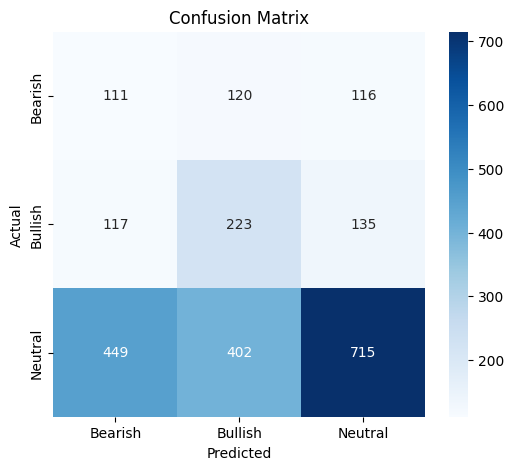

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 2. LSTM model

In [124]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded) # here there are hidden and cell because LSTM stores both short term memory (hidden) and long term memory (cell)
        # Unlike Simple RNN which only remembers short term memory (hidden)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

In [125]:
vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
num_classes = 3

lstm_model = LSTMModel(vocab_size, embedding_dim, hidden_dim, num_classes)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

In [126]:
epochs = 10

for epoch in range(epochs):
    lstm_model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.0953
Epoch 2/10, Loss: 0.9725
Epoch 3/10, Loss: 0.8236
Epoch 4/10, Loss: 0.7136
Epoch 5/10, Loss: 0.6264
Epoch 6/10, Loss: 0.5096
Epoch 7/10, Loss: 0.3794
Epoch 8/10, Loss: 0.2649
Epoch 9/10, Loss: 0.1945
Epoch 10/10, Loss: 0.1494


In [ ]:
lstm_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        outputs = lstm_model(X_batch)
        predictions = torch.argmax(outputs, dim=1) # to simply pick the largest output value, for results
        all_preds.extend(predictions.tolist())
        all_labels.extend(y_batch.tolist())

In [128]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(classification_report(all_labels, all_preds))

Accuracy : 0.7751
Macro F1 : 0.6643
Precision: 0.7030
Recall   : 0.6453
              precision    recall  f1-score   support

           0       0.54      0.54      0.54       347
           1       0.74      0.48      0.58       475
           2       0.83      0.92      0.87      1566

    accuracy                           0.78      2388
   macro avg       0.70      0.65      0.66      2388
weighted avg       0.77      0.78      0.76      2388



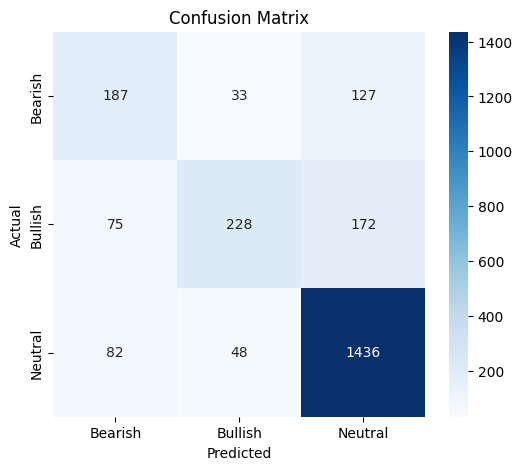

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 3. GRU model

In [130]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

In [131]:
vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
num_classes = 3

gru_model = GRUModel(vocab_size, embedding_dim, hidden_dim, num_classes)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

In [132]:
epochs = 10

for epoch in range(epochs):
    gru_model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = gru_model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.0981
Epoch 2/10, Loss: 0.9669
Epoch 3/10, Loss: 0.7686
Epoch 4/10, Loss: 0.5416
Epoch 5/10, Loss: 0.3280
Epoch 6/10, Loss: 0.1910
Epoch 7/10, Loss: 0.1076
Epoch 8/10, Loss: 0.0867
Epoch 9/10, Loss: 0.0585
Epoch 10/10, Loss: 0.0382


In [133]:
gru_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        outputs = gru_model(X_batch)
        predictions = torch.argmax(outputs, dim=1)
        all_preds.extend(predictions.tolist())
        all_labels.extend(y_batch.tolist())

In [134]:
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(classification_report(all_labels, all_preds))

Accuracy : 0.7969
Macro F1 : 0.7012
Precision: 0.7403
Recall   : 0.6748
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       347
           1       0.71      0.59      0.65       475
           2       0.83      0.92      0.88      1566

    accuracy                           0.80      2388
   macro avg       0.74      0.67      0.70      2388
weighted avg       0.79      0.80      0.79      2388



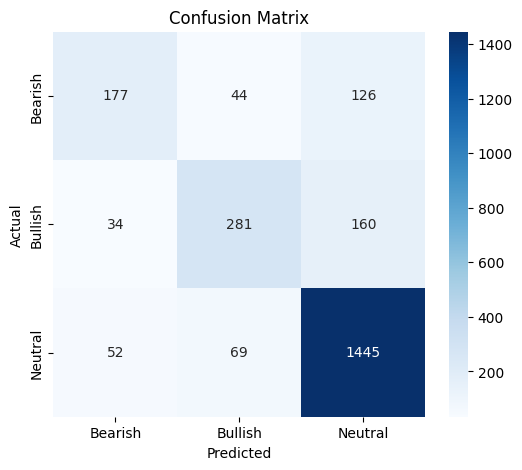

In [135]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 4. BERT

In [ ]:
import torch

from transformers import (BertTokenizer, BertForSequenceClassification)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [137]:
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=25,
    return_tensors="pt"
)

valid_encodings = tokenizer(
    valid_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=25,
    return_tensors="pt"
)

In [138]:
train_labels = torch.tensor(train_df["label"].tolist())
valid_labels = torch.tensor(valid_df["label"].tolist())

In [139]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(train_encodings["input_ids"], train_encodings["attention_mask"], train_labels)
valid_dataset = TensorDataset(valid_encodings["input_ids"], valid_encodings["attention_mask"], valid_labels)

In [140]:
from torch.utils.data import DataLoader

train_loader_bert = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader_bert = DataLoader(valid_dataset, batch_size=32)

In [141]:
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [143]:
epochs = 3

bert_model.train()

for epoch in range(epochs):
    total_loss = 0

    for input_ids, attention_mask, labels in train_loader_bert:
        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 0.5617
Epoch 2/3, Loss: 0.2864
Epoch 3/3, Loss: 0.1578


In [144]:
bert_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in valid_loader_bert:

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(classification_report(all_labels, all_preds))

Accuracy : 0.8677
Macro F1 : 0.8303
Precision: 0.8173
Recall   : 0.8572
              precision    recall  f1-score   support

           0       0.65      0.89      0.76       347
           1       0.86      0.79      0.82       475
           2       0.94      0.88      0.91      1566

    accuracy                           0.87      2388
   macro avg       0.82      0.86      0.83      2388
weighted avg       0.88      0.87      0.87      2388



Model Comparison:
Simple RNN gave the lowest performance as it struggles to remember long-term information. LSTM improved the results by remembering important information for longer, while GRU performed slightly better with a simpler and more efficient memory mechanism. Among the RNN models, GRU achieved the best performance.

Best Model:
BERT achieved the highest performance with the best Accuracy and Macro F1-score. Unlike the RNN models, BERT is a pretrained transformer that understands the context of the entire sentence, making it more accurate for financial sentiment classification.

In [ ]:
# to save the best model (bert) and its tokenizer

torch.save(bert_model.state_dict(), "bert_model.pth")
tokenizer.save_pretrained("bert_tokenizer")

('bert_tokenizer/tokenizer_config.json', 'bert_tokenizer/tokenizer.json')